# 15 - Empirical variable construction

This notebook constructs USDJPY empirical state variables without causal, forecasting, or event-effect analysis.

## Volatility, variance and the empirical state variables

The economic object is volatility, but the main states are variances. If $\sigma_t$ is volatility, variance is $\sigma_t^2$. One-hour log returns produce **realised variance** by squaring and summing return increments. Bloomberg supplies **implied volatility** quote points: decimal implied volatility is $q_t/100$ and annualised **implied variance** is $(q_t/100)^2$. Realised volatility is the square root of realised variance and is not the primary downstream state.

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

pd.set_option('display.max_columns', 50)
NY = ZoneInfo('America/New_York')
PRIMARY_MIN_VALID_HOURS = 24
PROJECT_MARKER = "00_model_specification_and_core_simulator.ipynb"

def find_project_root(start=None):
    """Find the project from the current directory or one of its parents."""
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "Data").is_dir() and (candidate / PROJECT_MARKER).is_file():
            return candidate
    raise RuntimeError(
        "Could not locate the FX volatility project root. "
        "Start the notebook from the project directory or one of its subdirectories; "
        f"expected both Data/ and {PROJECT_MARKER}."
    )

PROJECT_ROOT = find_project_root()
INTERIM, PROCESSED = PROJECT_ROOT / 'Data' / 'interim', PROJECT_ROOT / 'Data' / 'processed'
PROCESSED.mkdir(exist_ok=True)
PREVIOUS_PANEL_PATH = PROCESSED / 'usdjpy_daily_model_panel.csv'
previous_panel = pd.read_csv(PREVIOUS_PANEL_PATH, parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True) if PREVIOUS_PANEL_PATH.exists() else None
FROZEN_16_PANEL_PATH = PROCESSED / '16_empirical_analysis_panel.csv'
RUN_ID = pd.Timestamp.now(tz='UTC').isoformat()
print(f'Project root: {PROJECT_ROOT}')
print(f'Primary RV rule: {PRIMARY_MIN_VALID_HOURS}/24 valid hourly returns, a non-stale complete session, and unscaled RV.')

Project root: <PROJECT_ROOT>
Primary RV rule: 24/24 valid hourly returns, a non-stale complete session, and unscaled RV.


## 1. Audited inputs and frozen conventions

Notebook 14 remains the audit authority. This notebook consumes its CSV outputs without re-auditing raw data. The 1D ATM implied-volatility quote time, timezone, and exact overnight day-count remain unresolved.

In [26]:
hourly = pd.read_csv(INTERIM / 'usdjpy_hourly_mid_audited.csv', parse_dates=['timestamp', 'timestamp_parsed'])
iv = pd.read_csv(INTERIM / 'usdjpy_atm_1d_audited.csv', parse_dates=['date'])
events = pd.read_csv(INTERIM / 'g10_usd_jpy_events_audited.csv')
boj = pd.read_csv(INTERIM / 'boj_calendar_audited.csv')
inventory = pd.read_csv(INTERIM / 'empirical_source_inventory.csv')
coverage_audit = pd.read_csv(INTERIM / 'empirical_coverage_summary.csv')
quality_audit = pd.read_csv(INTERIM / 'empirical_data_quality_issues.csv')
hourly['timestamp'] = pd.to_datetime(hourly['timestamp'], utc=True)
hourly['timestamp_parsed'] = pd.to_datetime(hourly['timestamp_parsed'], utc=True)
events['event_datetime_utc'] = pd.to_datetime(events['event_datetime_utc'], utc=True, format='mixed')
events['event_date_utc'] = pd.to_datetime(events['event_date_utc'], utc=True, format='mixed')
print({'hourly_rows': len(hourly), 'iv_rows': len(iv), 'event_rows': len(events), 'boj_supplement_rows': len(boj)})
display(inventory[['source_name', 'intended_role', 'status']])
display(coverage_audit)
display(quality_audit[['Issue', 'Source', 'Status']])

{'hourly_rows': 149842, 'iv_rows': 6452, 'event_rows': 16880, 'boj_supplement_rows': 108}


,source_name,intended_role,status
0,usdjpy_hourly_mid.csv,Primary native Dukascopy 1-hour USDJPY midpoin...,Primary
1,usdjpy_hourly_bid.csv,Bid-side cross-check for hourly midpoint,Supplementary / audit
2,usdjpy_hourly_ask.csv,Ask-side cross-check for hourly midpoint,Supplementary / audit
3,ATM volatility workbook,Bloomberg PX_LAST for USDJPYVON BGN Curncy; pr...,Primary
4,G10 macro calendar,USD and JPY scheduled macro events,Primary
5,Dedicated BoJ calendar,BoJ meeting-date/timezone cross-check; not pri...,Supplementary / audit
6,Daily bid/ask/last workbook,Supplementary daily USDJPY cross-check,Supplementary / audit
7,Legacy hourly bid/ask/last workbook,Supplementary hourly USDJPY cross-check,Supplementary / audit
8,25R workbook,Broader options dataset; not required for ATM ...,Supplementary / inventory only
9,25B workbook,Broader options dataset; not required for ATM ...,Supplementary / inventory only


,source,start,end,observations,role,broad_feasible_start,broad_feasible_end,effective_start_driver
0,New hourly USDJPY midpoint,2003-05-04,2026-07-01,149842,Primary intraday spot,2003-05-04,2026-07-01,hourly USDJPY
1,Legacy daily USDJPY,1986-06-10,2026-06-10,10437,Supplementary spot,2003-05-04,2026-07-01,hourly USDJPY
2,USDJPY 1D ATM IV,1970-01-01,2026-07-01,6452,Primary daily IV,2003-05-04,2026-07-01,hourly USDJPY
3,USD macro events,1997-01-02,2026-07-01,12130,Primary event calendar subset,2003-05-04,2026-07-01,hourly USDJPY
4,JPY macro events,1997-01-13,2026-07-01,4750,Primary event calendar subset,2003-05-04,2026-07-01,hourly USDJPY
5,Dedicated BoJ events (UTC),2015-01-21,2026-06-15,108,Supplementary BoJ meeting-date/timezone cross-...,2003-05-04,2026-07-01,hourly USDJPY


,Issue,Source,Status
0,Hourly sampling gaps,New hourly midpoint,Classified
1,Populated weekend / stale timestamps,New hourly midpoint,Observed
2,Major internal hourly outage,New hourly midpoint,Observed
3,Supplied-return-across-gap risk,New hourly midpoint,Flagged
4,Hourly timestamp timezone,New hourly midpoint,Resolved from source strings
5,Hourly OHLC / spread integrity,New hourly midpoint and bid/ask files,Audited
6,1D ATM quote cut/timezone,Bloomberg ATM PX_LAST,Partially resolved
7,1D ATM horizon / total-variance convention,Bloomberg ATM PX_LAST,Unresolved
8,Extraction reproducibility metadata,Dukascopy / Bloomberg,Partially unresolved
9,Long 1D ATM date gaps,ATM workbook,Audited


## 2. The 17:00 New York model day

A model day is labelled by the date on which it **ends**. If $c_t$ is that date's 17:00 New York cut, define its start as $s_t=c_t-1\text{ calendar day}$ and its session as $[s_t,c_t)$; the start is included and the end excluded. For Monday, $s_{\text{Monday}}$ is Sunday 17:00 New York and $c_{\text{Monday}}$ is Monday 17:00 New York. Boundaries are constructed in `America/New_York` then converted to UTC, so daylight-saving time is handled dynamically rather than by a hard-coded UTC hour.

| Model day | Model session begins | Model session ends | First hourly candle |
| --- | --- | --- | --- |
| Monday | Sunday 17:00 New York | Monday 17:00 New York | Sunday 17:00-18:00 |
| Tuesday | Monday 17:00 New York | Tuesday 17:00 New York | Monday 17:00-18:00 |
| Wednesday | Tuesday 17:00 New York | Wednesday 17:00 New York | Tuesday 17:00-18:00 |
| Thursday | Wednesday 17:00 New York | Thursday 17:00 New York | Wednesday 17:00-18:00 |
| Friday | Thursday 17:00 New York | Friday 17:00 New York | Thursday 17:00-18:00 |

A Dukascopy row timestamped $h$ represents approximately $[h,h+1\text{ hour})$. Thus a 09:00 candle spans 09:00 up to, but not including, 10:00; `mid_open` is its beginning price and `mid_close` is approximately its ending price. The final candle of a model day begins one hour before the 17:00 New York cut.

In [27]:
def model_day_from_candle_start(ts):
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize('UTC')
    local = ts.tz_convert(NY)
    day = local.normalize() + pd.Timedelta(days=int((local.hour, local.minute, local.second, local.microsecond) >= (17, 0, 0, 0)))
    return day.date() if day.weekday() < 5 else pd.NaT

def make_sessions(first_day, last_day):
    days = pd.bdate_range(first_day, last_day)
    end_ny = pd.DatetimeIndex([pd.Timestamp(d.date()).tz_localize(NY) + pd.Timedelta(hours=17) for d in days])
    out = pd.DataFrame({'model_day': pd.to_datetime(days.date), 'session_end_ny': end_ny})
    out['session_start_ny'] = out['session_end_ny'] - pd.DateOffset(days=1)
    out['session_start_utc'] = out['session_start_ny'].dt.tz_convert('UTC')
    out['session_end_utc'] = out['session_end_ny'].dt.tz_convert('UTC')
    out['expected_hourly_return_count'] = ((out['session_end_utc'] - out['session_start_utc']).dt.total_seconds() / 3600).astype(int)
    return out

hourly['model_day'] = hourly['timestamp'].map(model_day_from_candle_start)
first_day = pd.to_datetime(hourly['model_day'].dropna()).min().date()
last_day = pd.to_datetime(hourly['model_day'].dropna()).max().date()
sessions = make_sessions(first_day, last_day)
assert (sessions['session_start_ny'].dt.hour == 17).all() and (sessions['session_end_ny'].dt.hour == 17).all()
assert (sessions['session_start_utc'].iloc[1:].to_numpy() >= sessions['session_end_utc'].iloc[:-1].to_numpy()).all()
ordinary = sessions['model_day'].iloc[1:].dt.weekday.ne(0).to_numpy()
assert (sessions['session_start_utc'].iloc[1:].to_numpy()[ordinary] == sessions['session_end_utc'].iloc[:-1].to_numpy()[ordinary]).all()
probe = sessions.iloc[100]
assert model_day_from_candle_start(probe['session_end_utc']) == sessions.iloc[101]['model_day'].date()
print(f'{len(sessions):,} sessions: {sessions.model_day.min().date()} to {sessions.model_day.max().date()}')

6,044 sessions: 2003-05-05 to 2026-07-02


## 3. Hourly log-return construction

For later hours in a model day, the code uses consecutive candle closes:

$$r_{t,h}=\ln\left(\frac{C_{t,h}}{C_{t,h-1}}\right),\qquad h=2,\ldots,24.$$

It constructs this only for genuinely adjacent candles in the same session: a missing multi-hour interval is not bridged.

### First hour of every model day

The first within-session return is open-to-close within the new candle,

$$r_{t,1}=\ln\left(\frac{C_{t,1}}{O_{t,1}}\right),$$

not $\log(C_{t,1}/C_{t-1,24})$. This prevents movement between the old session endpoint and the new opening from being mixed into the first trading-hour return. Hence a complete day contains $r_{t,1},r_{t,2},\ldots,r_{t,24}$.

*Illustrative example only:* if the first candle opens at 147.20 and closes at 147.35, then $\log(147.35/147.20)\approx0.001018$, about a 0.102% log return during that first trading hour.

In [28]:
hourly = hourly.sort_values('timestamp').reset_index(drop=True)
hourly['candle_end_utc'] = hourly['timestamp'] + pd.Timedelta(hours=1)
hourly['timestamp_ny'] = hourly['timestamp'].dt.tz_convert(NY)
hourly['model_day'] = hourly['timestamp'].map(model_day_from_candle_start)
hourly['model_day'] = pd.to_datetime(hourly['model_day'])
for c in ['mid_open', 'mid_high', 'mid_low', 'mid_close']:
    hourly[c] = pd.to_numeric(hourly[c], errors='coerce')
hourly['audit_row_valid'] = hourly[['mid_open', 'mid_high', 'mid_low', 'mid_close']].gt(0).all(axis=1)
hourly['previous_timestamp'] = hourly['timestamp'].shift()
hourly['previous_mid_close'] = hourly['mid_close'].shift()
hourly['adjacent_previous_hour'] = hourly['timestamp'].diff().eq(pd.Timedelta(hours=1))
hourly['is_session_first_candle'] = hourly['timestamp'].isin(set(sessions['session_start_utc']))
hourly['hourly_log_return'] = np.nan
hourly['return_reason'] = 'outside_model_session_or_invalid_audit'
continuation = hourly['model_day'].notna() & hourly['audit_row_valid'] & hourly['audit_row_valid'].shift(fill_value=False) & hourly['adjacent_previous_hour'] & hourly['model_day'].eq(hourly['model_day'].shift())
opening = hourly['model_day'].notna() & hourly['audit_row_valid'] & hourly['is_session_first_candle']
hourly.loc[continuation, 'hourly_log_return'] = np.log(hourly.loc[continuation, 'mid_close'] / hourly.loc[continuation, 'previous_mid_close'])
hourly.loc[continuation, 'return_reason'] = 'adjacent_within_session_close_to_close'
hourly.loc[opening, 'hourly_log_return'] = np.log(hourly.loc[opening, 'mid_close'] / hourly.loc[opening, 'mid_open'])
hourly.loc[opening, 'return_reason'] = 'session_open_to_close'
hourly.loc[opening & pd.to_datetime(hourly['model_day']).dt.weekday.eq(0), 'return_reason'] = 'first_post_weekend_session_open_to_close'
missing_previous = hourly['model_day'].notna() & hourly['audit_row_valid'] & ~hourly['is_session_first_candle'] & ~continuation
hourly.loc[missing_previous, 'return_reason'] = 'invalid_missing_previous_hour'
hourly['valid_within_session_return'] = hourly['hourly_log_return'].notna()
hourly['squared_within_session_return'] = hourly['hourly_log_return'].pow(2)
assert hourly.loc[hourly['valid_within_session_return'], 'return_reason'].isin(['adjacent_within_session_close_to_close', 'session_open_to_close', 'first_post_weekend_session_open_to_close']).all()
print(hourly['return_reason'].value_counts().to_string())

return_reason
adjacent_within_session_close_to_close      133877
outside_model_session_or_invalid_audit       10076
session_open_to_close                         4669
first_post_weekend_session_open_to_close      1140
invalid_missing_previous_hour                   80


## 4. Completeness, realised variance, and weekend reopening movements

### The 24/24 non-stale completeness rule

Primary realised variance requires 24/24 valid hourly returns **and** a non-stale complete session. The raw within-session realised variance is retained before this primary mask. For this USDJPY hourly source, a technically complete session with zero raw realised variance has 24 accepted zero returns and is treated as a populated stale market-closure session, rather than as a genuine zero-volatility trading day. This is an empirical data-quality convention; it does not alter the raw calculation or the separate closure-gap sensitivity construction.

In [29]:
inside = hourly.loc[hourly['model_day'].notna()].copy()
inside['model_day'] = pd.to_datetime(inside['model_day'])
aggregated = inside.groupby('model_day', as_index=False).agg(
    observed_hourly_count=('timestamp', 'size'),
    valid_hourly_return_count=('valid_within_session_return', 'sum'),
    within_session_log_return_raw=('hourly_log_return', lambda x: x.sum(min_count=1)),
    rv_within_raw=('squared_within_session_return', lambda x: x.sum(min_count=1)),
)
daily = sessions.merge(aggregated, on='model_day', how='left')
for c in ['observed_hourly_count', 'valid_hourly_return_count']:
    daily[c] = daily[c].fillna(0).astype(int)
daily['valid_hourly_count'] = daily['valid_hourly_return_count']
daily['expected_hourly_count'] = daily['expected_hourly_return_count']
daily['coverage_ratio'] = daily['valid_hourly_return_count'] / daily['expected_hourly_return_count']

# Exact start open and exact endpoint close: endpoint candle is [end-1h, end).
starts = hourly[['timestamp', 'mid_open', 'audit_row_valid']].rename(columns={'timestamp': 'session_start_utc', 'mid_open': 'session_open_price', 'audit_row_valid': 'session_open_valid'})
ends = hourly[['timestamp', 'mid_close', 'audit_row_valid']].rename(columns={'timestamp': 'endpoint_candle_start_utc', 'mid_close': 'session_end_price', 'audit_row_valid': 'session_end_valid'})
daily['endpoint_candle_start_utc'] = daily['session_end_utc'] - pd.Timedelta(hours=1)
daily = daily.merge(starts, on='session_start_utc', how='left').merge(ends, on='endpoint_candle_start_utc', how='left')
daily['session_open_valid'] = daily['session_open_valid'].astype('boolean').fillna(False).astype(bool)
daily['session_end_valid'] = daily['session_end_valid'].astype('boolean').fillna(False).astype(bool)
daily['previous_model_day'] = daily['model_day'].shift()
daily['previous_session_end_price'] = daily['session_end_price'].shift()
daily['previous_session_end_valid'] = daily['session_end_valid'].shift(fill_value=False)
daily['session_boundary_gap_log_return'] = np.where(
    daily['session_open_valid'] & daily['previous_session_end_valid'],
    np.log(daily['session_open_price'] / daily['previous_session_end_price']), np.nan
)
daily['is_monday'] = daily['model_day'].dt.weekday.eq(0)
daily['eligible_monday_session'] = daily['is_monday'] & daily['previous_model_day'].dt.weekday.eq(4)
daily['weekend_gap_missing_reason'] = pd.NA
weekend_ok = daily['eligible_monday_session'] & daily['session_open_valid'] & daily['previous_session_end_valid']
daily['closure_gap_type'] = np.where(weekend_ok, 'weekend', np.where(daily['eligible_monday_session'], 'unresolved_data_gap', 'none'))
daily.loc[daily['eligible_monday_session'] & ~weekend_ok & ~daily['previous_session_end_valid'] & ~daily['session_open_valid'], 'weekend_gap_missing_reason'] = 'Friday endpoint and Sunday reopening unavailable'
daily.loc[daily['eligible_monday_session'] & ~weekend_ok & ~daily['previous_session_end_valid'] & daily['session_open_valid'], 'weekend_gap_missing_reason'] = 'Friday endpoint unavailable'
daily.loc[daily['eligible_monday_session'] & ~weekend_ok & daily['previous_session_end_valid'] & ~daily['session_open_valid'], 'weekend_gap_missing_reason'] = 'Sunday 17:00 reopening candle unavailable'
daily['closure_gap_log_return'] = np.where(weekend_ok, daily['session_boundary_gap_log_return'], np.where(daily['eligible_monday_session'], np.nan, 0.0))
# Independent endpoint-to-endpoint construction; never assigned from component returns.
daily['total_cut_to_cut_log_return'] = np.where(
    daily['session_end_valid'] & daily['previous_session_end_valid'],
    np.log(daily['session_end_price'] / daily['previous_session_end_price']), np.nan
)
daily['rv_with_closure_gap_raw'] = np.where(
    daily['rv_within_raw'].notna() & daily['closure_gap_log_return'].notna(),
    daily['rv_within_raw'] + daily['closure_gap_log_return'].pow(2), np.nan
)

# Primary RV requires a complete 24-hour session and strictly positive raw RV.
daily['rv_complete_24h'] = daily['valid_hourly_return_count'].eq(PRIMARY_MIN_VALID_HOURS)
daily['rv_eligible_before_stale_filter'] = daily['rv_complete_24h']
daily['rv_full_session_stale'] = daily['rv_complete_24h'] & daily['rv_within_raw'].le(0).fillna(False)
daily['rv_eligible'] = daily['rv_complete_24h'] & ~daily['rv_full_session_stale']
# Canonical modelling quantities are masked unless complete and non-stale; raw values remain diagnostic only.
daily['within_session_log_return'] = daily['within_session_log_return_raw'].where(daily['rv_eligible'])
daily['rv_within'] = daily['rv_within_raw'].where(daily['rv_eligible'])
daily['rv_with_closure_gap'] = daily['rv_with_closure_gap_raw'].where(daily['rv_eligible'])

# Attach the corrected boundary classification only to exact session-opening candles in the hourly export.
hourly['closure_gap_type'] = 'none'
hourly['closure_gap_log_return'] = np.nan
opening_daily = daily[['model_day', 'closure_gap_type', 'closure_gap_log_return']].copy()
hourly = hourly.merge(opening_daily, on='model_day', how='left', suffixes=('', '_daily'))
opening_rows = hourly['is_session_first_candle']
hourly.loc[opening_rows, 'closure_gap_type'] = hourly.loc[opening_rows, 'closure_gap_type_daily'].fillna('none')
hourly.loc[opening_rows, 'closure_gap_log_return'] = hourly.loc[opening_rows, 'closure_gap_log_return_daily']
hourly = hourly.drop(columns=['closure_gap_type_daily', 'closure_gap_log_return_daily'])

known_stale_dates = pd.to_datetime(['2013-01-01', '2014-01-01'])
known_stale_rows = daily['model_day'].isin(known_stale_dates)
assert known_stale_rows.sum() == len(known_stale_dates)
assert (daily.loc[known_stale_rows, 'valid_hourly_return_count'] == PRIMARY_MIN_VALID_HOURS).all()
assert (~daily.loc[known_stale_rows, 'rv_eligible']).all()
assert daily.loc[known_stale_rows, 'rv_full_session_stale'].all()
assert daily['rv_within'].notna().eq(daily['rv_eligible']).all()
assert (daily.loc[daily['rv_eligible'], 'rv_within'] >= 0).all()
assert not (daily['rv_full_session_stale'] & daily['rv_eligible']).any()
assert (daily.loc[daily['rv_full_session_stale'], 'valid_hourly_return_count'] == PRIMARY_MIN_VALID_HOURS).all()
assert (daily.loc[daily['rv_eligible'], 'valid_hourly_return_count'] == PRIMARY_MIN_VALID_HOURS).all()
assert daily.loc[~daily['rv_eligible'], 'rv_within'].isna().all()
assert daily.loc[daily['rv_eligible'], 'rv_within'].notna().all()
assert np.allclose(daily.loc[daily['rv_eligible'], 'rv_within'], daily.loc[daily['rv_eligible'], 'rv_within_raw'])
assert daily.loc[~daily['rv_eligible'], 'within_session_log_return'].isna().all()
assert np.allclose(daily.loc[daily['rv_eligible'], 'within_session_log_return'], daily.loc[daily['rv_eligible'], 'within_session_log_return_raw'])
assert daily.loc[~daily['rv_eligible'], 'rv_with_closure_gap'].isna().all()
assert np.allclose(daily.loc[weekend_ok, 'closure_gap_log_return'], daily.loc[weekend_ok, 'session_boundary_gap_log_return'])
assert not daily.loc[daily['model_day'].between('2010-01-01', '2010-10-01'), 'closure_gap_type'].eq('weekend').any()
print(f'Primary RV retention after stale-session filter: {daily.rv_eligible.sum():,}/{len(daily):,} ({daily.rv_eligible.mean():.1%})')

Primary RV retention after stale-session filter: 5,762/6,044 (95.3%)


## Full-session stale-quote audit

Complete sessions with non-positive raw within-session realised variance are shown below. They are excluded from the primary state because all accepted hourly returns are zero; raw quantities remain available for audit.


In [30]:
stale_audit_columns = [
    'model_day', 'valid_hourly_return_count', 'rv_complete_24h',
    'rv_within_raw', 'rv_full_session_stale', 'rv_eligible', 'rv_within',
]
full_session_stale_audit = daily.loc[
    daily['rv_complete_24h'] & daily['rv_within_raw'].le(0).fillna(False),
    stale_audit_columns,
].copy()
print('Primary RV eligibility before stale-session filter:', int(daily['rv_eligible_before_stale_filter'].sum()))
print('Primary RV eligibility after stale-session filter:', int(daily['rv_eligible'].sum()))
print('Excluded by full-session staleness rule:', int(daily['rv_full_session_stale'].sum()))
display(full_session_stale_audit.sort_values('model_day'))

Primary RV eligibility before stale-session filter: 5764
Primary RV eligibility after stale-session filter: 5762
Excluded by full-session staleness rule: 2


,model_day,valid_hourly_return_count,rv_complete_24h,rv_within_raw,rv_full_session_stale,rv_eligible,rv_within
2521,2013-01-01,24,True,0.0,True,False,NaN
2782,2014-01-01,24,True,0.0,True,False,NaN


## Session-boundary gap, cut-to-cut return, and closure-gap sensitivity

The boundary movement is $b_t=\log(P_t^{open}/P_{t-1}^{end})$ and the within-session movement is $r_t^{within}=\log(P_t^{end}/P_t^{open})$. The independently constructed cut-to-cut return is $r_t^{cut-to-cut}=\log(P_t^{end}/P_{t-1}^{end})$. Logarithmic additivity gives

$$\log\left(\frac{P_t^{open}}{P_{t-1}^{end}}\right)+\log\left(\frac{P_t^{end}}{P_t^{open}}\right)=\log\left(\frac{P_t^{end}}{P_{t-1}^{end}}\right).$$

The notebook verifies this endpoint-based equality numerically rather than defining cut-to-cut return as a sum. For Monday, the boundary movement is the weekend reopening movement when valid boundary prices exist; unexplained outages are not classified as closures.

The sensitivity `rv_with_closure_gap_raw` is raw within-session realised variance plus $g_t^2$, then `rv_with_closure_gap` is masked by eligibility. This is not $(g_t+r_t^{within})^2$: realised variance squares each distinct return increment, so a discrete weekend movement contributes its own $g_t^2$. Primary realised variance remains `rv_within`.

In [31]:
weekend_year = daily.loc[daily['eligible_monday_session']].assign(year=lambda x: x['model_day'].dt.year).groupby('year', as_index=False).agg(
    eligible_monday_sessions=('eligible_monday_session', 'size'),
    weekend_gap_constructed=('closure_gap_type', lambda x: (x == 'weekend').sum()),
    weekend_gap_missing=('closure_gap_type', lambda x: (x != 'weekend').sum()),
)
print('Weekend-gap validation by year:')
display(weekend_year)
missing_reasons = daily.loc[daily['eligible_monday_session'] & daily['closure_gap_type'].ne('weekend'), 'weekend_gap_missing_reason'].fillna('other/unresolved').value_counts().rename_axis('reason').reset_index(name='count')
print('Missing eligible-Monday gap reasons:')
display(missing_reasons)
weekend_stats = daily.loc[daily['closure_gap_type'].eq('weekend'), 'closure_gap_log_return'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print('Weekend-gap descriptive diagnostics:')
print(weekend_stats.to_string())
rv_year = daily.assign(year=daily['model_day'].dt.year).groupby('year', as_index=False).agg(model_days=('model_day', 'size'), rv_eligible_days=('rv_eligible', 'sum'), mean_valid_hourly_return_count=('valid_hourly_return_count', 'mean'))
rv_year['rv_eligible_pct'] = rv_year['rv_eligible_days'] / rv_year['model_days']
print('RV coverage by year:')
display(rv_year)

Weekend-gap validation by year:


,year,eligible_monday_sessions,weekend_gap_constructed,weekend_gap_missing
0,2003,34,32,2
1,2004,52,51,1
2,2005,52,52,0
3,2006,52,52,0
4,2007,53,53,0
5,2008,52,52,0
6,2009,52,52,0
7,2010,52,13,39
8,2011,52,52,0
9,2012,53,52,1


Missing eligible-Monday gap reasons:


,reason,count
0,Friday endpoint and Sunday reopening unavailable,40
1,Sunday 17:00 reopening candle unavailable,6
2,Friday endpoint unavailable,5


Weekend-gap descriptive diagnostics:
count     1157.000000
mean        -0.000146
median      -0.000110
std          0.001968
min         -0.012048
max          0.013744
RV coverage by year:


,year,model_days,rv_eligible_days,mean_valid_hourly_return_count,rv_eligible_pct
0,2003,173,167,23.878613,0.965318
1,2004,262,259,23.938931,0.988550
2,2005,260,258,23.957692,0.992308
3,2006,260,259,23.969231,0.996154
4,2007,261,260,23.969349,0.996169
5,2008,262,261,23.969466,0.996183
6,2009,261,260,23.969349,0.996169
7,2010,261,64,5.996169,0.245211
8,2011,260,259,23.969231,0.996154
9,2012,261,249,23.842912,0.954023


## 5. From implied volatility to raw implied variance

Bloomberg supplies an implied-volatility quote. If \(q_t=10\) quote points, decimal implied volatility is \(q_t/100=0.10\). The raw observed implied-variance state is \(I_t^{raw}=(q_t/100)^2\), retained in iv_ann_var. The weekday-normalised modelling state is constructed later without overwriting this raw quantity. Existing /252 and /365 fields remain sensitivity columns only; they are not confirmed Bloomberg conventions.

In [32]:
iv = iv.rename(columns={'date': 'model_day', 'iv': 'atm_vol_quote_points'}).copy()
iv['model_day'] = pd.to_datetime(iv['model_day'])
iv['atm_vol_quote_points'] = pd.to_numeric(iv['atm_vol_quote_points'], errors='coerce')
iv['implied_vol_decimal'] = iv['atm_vol_quote_points'] / 100.0
iv['iv_ann_var'] = iv['implied_vol_decimal'].pow(2)
iv['iv_var_252'] = iv['iv_ann_var'] / 252.0
iv['iv_var_365'] = iv['iv_ann_var'] / 365.0
iv['iv_timestamp_status'] = 'date_only_snapshot_unresolved'
# Backward-compatible aliases retained for existing downstream inspection.
iv['iv_quote_points'] = iv['atm_vol_quote_points']
iv['iv_ann_vol_decimal'] = iv['implied_vol_decimal']
iv['iv_var_per_252_sensitivity'] = iv['iv_var_252']
iv['iv_var_per_365_sensitivity'] = iv['iv_var_365']
assert np.allclose(iv['iv_ann_var'].dropna(), iv.loc[iv['iv_ann_var'].notna(), 'implied_vol_decimal'].pow(2))

## 6. Exact event-time assignment

Events are assigned by exact timezone-aware UTC timestamps, not calendar dates alone: $\text{session start}_t\le\tau_e<\text{session end}_t$. Events outside the empirical model-sample period are classified separately and are not treated as market-closure observations. In-sample events whose exact timestamps fall outside the active model sessions are flagged as occurring during a market closure.

Future scheduled-event indicators use ex-ante calendar time and currency only. Actual values, surprises, revisions, and other post-release fields never enter them. Same-date events are not labelled before or after the Bloomberg implied-volatility quote because the exact quote time remains unresolved.

In [33]:
session_lookup = sessions[['model_day', 'session_start_utc', 'session_end_utc']].sort_values('session_start_utc').copy()
session_lookup['forecast_origin_model_day'] = session_lookup['model_day'].shift()
sample_start, sample_end = session_lookup['session_start_utc'].iloc[0], session_lookup['session_end_utc'].iloc[-1]
events_mapped = pd.merge_asof(events.sort_values('event_datetime_utc').copy(), session_lookup, left_on='event_datetime_utc', right_on='session_start_utc', direction='backward')
events_mapped['event_outside_model_sample'] = events_mapped['event_datetime_utc'].lt(sample_start) | events_mapped['event_datetime_utc'].ge(sample_end)
events_mapped['event_in_rv_session'] = ~events_mapped['event_outside_model_sample'] & events_mapped['session_end_utc'].notna() & events_mapped['event_datetime_utc'].lt(events_mapped['session_end_utc'])
events_mapped['event_in_market_closure'] = ~events_mapped['event_outside_model_sample'] & ~events_mapped['event_in_rv_session']
events_mapped.loc[~events_mapped['event_in_rv_session'], ['model_day', 'forecast_origin_model_day']] = pd.NaT
events_mapped = events_mapped.rename(columns={'model_day': 'rv_model_day'})
events_mapped['event_status'] = np.select(
    [events_mapped['event_in_rv_session'], events_mapped['event_in_market_closure'], events_mapped['event_outside_model_sample']],
    ['mapped to RV session', 'market closure within sample', 'outside model sample'], default='other/unresolved'
)
assert len(events_mapped) == len(events)
assert not events_mapped.loc[events_mapped['event_outside_model_sample'], 'event_in_market_closure'].any()
assert events_mapped.loc[events_mapped['event_in_market_closure'], 'rv_model_day'].isna().all()
assert (events_mapped.loc[events_mapped['event_in_rv_session'], 'event_datetime_utc'] >= events_mapped.loc[events_mapped['event_in_rv_session'], 'session_start_utc']).all()
assert (events_mapped.loc[events_mapped['event_in_rv_session'], 'event_datetime_utc'] < events_mapped.loc[events_mapped['event_in_rv_session'], 'session_end_utc']).all()
event_status = events_mapped['event_status'].value_counts().reindex(['mapped to RV session', 'market closure within sample', 'outside model sample', 'other/unresolved'], fill_value=0).rename_axis('event status').reset_index(name='count')
print('Event mapping status:')
display(event_status)
print({'total_event_rows': len(events_mapped), 'in_sample_event_rows': int((~events_mapped.event_outside_model_sample).sum()), 'pre_sample_event_rows': int(events_mapped.event_datetime_utc.lt(sample_start).sum()), 'post_sample_event_rows': int(events_mapped.event_datetime_utc.ge(sample_end).sum())})

Event mapping status:


,event status,count
0,mapped to RV session,14813
1,market closure within sample,2
2,outside model sample,2065
3,other/unresolved,0


{'total_event_rows': 16880, 'in_sample_event_rows': 14815, 'pre_sample_event_rows': 2065, 'post_sample_event_rows': 0}


## 7. Forward implied variance and eligibility flags

The documented primary alignment is **implied variance at model day $t$ to realised variance at the next model day**. The realised variance dated $t$ describes the session ending at the date-$t$ 17:00 New York cut; the date-$t$ implied-variance observation is treated as forward-looking. Friday maps to Monday, not Saturday. Exact Bloomberg micro-timing is unresolved.

`joint_panel_eligible` requires complete current realised variance, available implied volatility, and event-calendar availability. It does not depend on future data. `forecast_pair_eligible` additionally requires valid realised variance for the next model day. Current-state dependence analysis should not remove a valid current observation merely because the following high-frequency session is incomplete; forecast evaluation genuinely needs that next-day target.

In [34]:
panel = daily.merge(iv.drop(columns=['date_diff', 'prior_iv_gap_over_3_days'], errors='ignore'), on='model_day', how='left')
panel['iv_available'] = panel['iv_ann_var'].notna()
panel['next_model_day'] = panel['model_day'].shift(-1)
panel['rv_next_model_day'] = panel['rv_within'].shift(-1)
panel['rv_with_closure_gap_next_model_day'] = panel['rv_with_closure_gap'].shift(-1)
panel['rv_next_model_day_eligible'] = panel['rv_eligible'].shift(-1).fillna(False).astype(bool)

# Counts use scheduled timestamp/currency only; no post-release columns enter this aggregation.
target_counts = events_mapped.loc[events_mapped['event_in_rv_session']].groupby('rv_model_day', as_index=False).agg(
    any_scheduled_event_next_session=('event', lambda x: bool(len(x))),
    scheduled_event_count_next_session=('event', 'size'),
    scheduled_us_event_count_next_session=('ccy', lambda x: (x.astype(str).str.upper() == 'USD').sum()),
    scheduled_jp_event_count_next_session=('ccy', lambda x: x.astype(str).str.upper().isin(['JPY', 'JP']).sum()),
)
origins = session_lookup[['model_day', 'forecast_origin_model_day']].rename(columns={'model_day': 'rv_model_day'})
event_origins = origins.merge(target_counts, on='rv_model_day', how='left').drop(columns='rv_model_day')
panel = panel.merge(event_origins, left_on='model_day', right_on='forecast_origin_model_day', how='left').drop(columns='forecast_origin_model_day')
for c in ['scheduled_event_count_next_session', 'scheduled_us_event_count_next_session', 'scheduled_jp_event_count_next_session']:
    panel[c] = panel[c].fillna(0).astype(int)
panel['any_scheduled_event_next_session'] = panel['any_scheduled_event_next_session'].astype('boolean').fillna(False).astype(bool)

# Current-session flags reuse the same exact event-to-model-day mapping. They are audit/factor-estimation flags only.
current_event_counts = events_mapped.loc[events_mapped['event_in_rv_session']].groupby('rv_model_day', as_index=False).agg(
    any_scheduled_event_current_session=('event', lambda x: bool(len(x))),
    scheduled_event_count_current_session=('event', 'size'),
    fomc_active_current_session=('event', lambda x: x.astype(str).str.contains('FOMC Rate Decision', case=False, na=False).any()),
    boj_active_current_session=('event', lambda x: x.astype(str).str.contains('BOJ Target Rate', case=False, na=False).any()),
)
panel = panel.merge(current_event_counts, left_on='model_day', right_on='rv_model_day', how='left').drop(columns='rv_model_day')
panel['any_scheduled_event_current_session'] = panel['any_scheduled_event_current_session'].astype('boolean').fillna(False).astype(bool)
panel['fomc_active_current_session'] = panel['fomc_active_current_session'].astype('boolean').fillna(False).astype(bool)
panel['boj_active_current_session'] = panel['boj_active_current_session'].astype('boolean').fillna(False).astype(bool)
panel['scheduled_event_count_current_session'] = panel['scheduled_event_count_current_session'].fillna(0).astype(int)
calendar_min = events_mapped['event_datetime_utc'].min().tz_localize(None).normalize()
calendar_max = events_mapped['event_datetime_utc'].max().tz_localize(None).normalize()
panel['event_data_available'] = panel['model_day'].between(calendar_min, calendar_max)
# Current-state eligibility intentionally excludes future-target availability.
panel['joint_panel_eligible'] = panel['rv_eligible'] & panel['iv_available'] & panel['event_data_available']
panel['forecast_pair_eligible'] = panel['joint_panel_eligible'] & panel['rv_next_model_day_eligible']

comparable = panel['rv_eligible'] & panel['session_boundary_gap_log_return'].notna() & panel['total_cut_to_cut_log_return'].notna()
panel['cut_to_cut_decomposition_abs_diff'] = np.where(comparable, np.abs(panel['total_cut_to_cut_log_return'] - (panel['session_boundary_gap_log_return'] + panel['within_session_log_return'])), np.nan)
cut_stats = panel.loc[comparable, 'cut_to_cut_decomposition_abs_diff'].agg(['count', 'max', 'median', lambda x: x.quantile(0.99)])
cut_stats.index = ['comparable_eligible_sessions', 'max_abs_difference', 'median_abs_difference', 'p99_abs_difference']
assert (panel.loc[comparable, 'cut_to_cut_decomposition_abs_diff'] < 1e-10).all()
assert pd.isna(panel.iloc[-1]['next_model_day']) and pd.isna(panel.iloc[-1]['rv_next_model_day'])
assert panel['joint_panel_eligible'].eq(panel['rv_eligible'] & panel['iv_available'] & panel['event_data_available']).all()
assert panel['forecast_pair_eligible'].eq(panel['joint_panel_eligible'] & panel['rv_next_model_day_eligible']).all()
assert panel.loc[~panel['rv_next_model_day_eligible'], 'rv_next_model_day'].isna().all()
assert panel.loc[~panel['rv_next_model_day_eligible'], 'rv_with_closure_gap_next_model_day'].isna().all()
print('Independent cut-to-cut decomposition check:')
print(cut_stats.to_string())
availability = pd.Series({
    'RV available only': int((panel.rv_eligible & ~panel.iv_available).sum()),
    'IV available only': int((~panel.rv_eligible & panel.iv_available).sum()),
    'both RV and IV available': int((panel.rv_eligible & panel.iv_available).sum()),
    'neither': int((~panel.rv_eligible & ~panel.iv_available).sum()),
})
print('RV/IV availability:')
print(availability.to_string())
eligibility_report = pd.Series({
    'RV eligible': int(panel['rv_eligible'].sum()),
    'IV available': int(panel['iv_available'].sum()),
    'Current joint panel eligible': int(panel['joint_panel_eligible'].sum()),
    'Forecast pair eligible': int(panel['forecast_pair_eligible'].sum()),
    'Current joint lost solely because next RV unavailable': int((panel['joint_panel_eligible'] & ~panel['forecast_pair_eligible']).sum()),
})
print('Eligibility bookkeeping:')
print(eligibility_report.to_string())
assert panel['model_day'].is_monotonic_increasing and panel['model_day'].is_unique
assert panel['rv_within'].notna().eq(panel['rv_eligible']).all()
assert not (panel['rv_full_session_stale'] & panel['rv_eligible']).any()


Independent cut-to-cut decomposition check:
comparable_eligible_sessions    5.742000e+03
max_abs_difference              1.030426e-15
median_abs_difference           1.780849e-16
p99_abs_difference              6.482916e-16
RV/IV availability:
RV available only            319
IV available only            276
both RV and IV available    5443
neither                        6
Eligibility bookkeeping:
RV eligible                                              5762
IV available                                             5719
Current joint panel eligible                             5443
Forecast pair eligible                                   5368
Current joint lost solely because next RV unavailable      75


## Weekday-normalised implied variance

The raw Bloomberg state remains I_t^{raw}=(q_t/100)^2 in iv_ann_var. The frozen canonical state applies a multiplicative weekday seasonal adjustment using ALL finite training-period IV observations: I_t^{norm}=I_t^{raw}/s_{weekday(t)}^{ALL_TRAIN}. The aligned model-day weekday is used; neither IV nor events are shifted.

For weekday d, s_d=M_d/M, where M_d and M are respectively the weekday and pooled training medians of raw implied variance. Both have variance-rate units, hence [s_d]=1 and [I_t^{norm}]=[I_t^{raw}]. This changes the level of implied variance, not its physical units: it is neither annualisation, de-annualisation, 252/365 scaling, total implied variance, nor a confirmed vendor day-count correction.


## Frozen weekday-factor reference-sample decision

The completed training-only audit retains all four candidate reference samples. The final methodological decision is PRIMARY: ALL_TRAIN and ROBUSTNESS: EXCL_POLICY. EXCL_MAJOR_MACRO remains an additional audit, while EXCL_ANY_SCHEDULED is rejected as the primary estimator because routine calendar releases leave an excessively small and unbalanced Wednesday/Thursday reference sample.

This decision does not identify the source of the weekday structure. The raw Bloomberg overnight ATM implied-variance series exhibits a strong, repeatable weekday pattern, particularly a depressed Friday level. The canonical weekday-normalised implied variance removes that deterministic multiplicative component without assuming a Bloomberg fixing time, weekend-maturity convention, ACT/365 convention, or other vendor mechanism. Event observations remain in the final panel; the robust median estimates a typical weekday scale rather than treating event dates as eventless.


,training_iv_model_days,any_scheduled_event_days,any_scheduled_event_fraction,no_scheduled_event_days,no_scheduled_event_fraction
0,3302,2783,0.842823,519,0.157177


,ccy,event,event_rows,unique_model_days
36,USD,Initial Jobless Claims,678,678
38,USD,MBA Mortgage Applications,639,639
7,JPY,Industrial Production MoM,297,297
47,USD,U. of Mich. Sentiment,278,278
26,USD,Durable Goods Orders,164,164
49,USD,Wholesale Inventories MoM,163,163
37,USD,Leading Index,159,159
12,JPY,S&P Global Japan PMI Mfg,158,158
27,USD,Empire Manufacturing,157,157
32,USD,Housing Starts,157,155


,requested_category,exact_labels_matched,event_rows,unique_model_days_excluded
0,US FOMC policy decision,FOMC Rate Decision (Upper Bound),103,103
1,Japan BoJ policy decision,BOJ Target Rate,146,146
2,US payrolls,Change in Nonfarm Payrolls,144,144
3,US CPI,CPI MoM; CPI YoY,304,152
4,US GDP,GDP Annualized QoQ,149,149
5,US retail sales,Retail Sales Advance MoM,155,155
6,Japan CPI,Natl CPI YoY; Tokyo CPI Ex-Fresh Food YoY,276,138
7,Japan GDP,GDP Annualized SA QoQ; GDP SA QoQ; GDP Deflato...,279,93


iv_weekday,candidate,total_n,Monday_n,Tuesday_n,Wednesday_n,Thursday_n,Friday_n,LOW_SAMPLE_WARNING
0,ALL_TRAIN,3302,667,674,671,678,612,False
1,EXCL_ANY_SCHEDULED,519,269,142,17,15,76,True
2,EXCL_MAJOR_MACRO,2376,612,526,490,498,250,False
3,EXCL_POLICY,3061,663,605,581,637,575,False


,iv_weekday,n,weekday_raw_median,candidate,pooled_raw_median,scale_factor,inverse_scale_factor
0,Monday,667,0.012100,ALL_TRAIN,0.011889,1.017732,0.982577
1,Tuesday,674,0.012519,ALL_TRAIN,0.011889,1.052960,0.949703
2,Wednesday,671,0.013806,ALL_TRAIN,0.011889,1.161245,0.861145
3,Thursday,678,0.015625,ALL_TRAIN,0.011889,1.314220,0.760907
4,Friday,612,0.005649,ALL_TRAIN,0.011889,0.475134,2.104670
5,Monday,663,0.012100,EXCL_POLICY,0.011664,1.037380,0.963967
6,Tuesday,605,0.012321,EXCL_POLICY,0.011664,1.056327,0.946676
7,Wednesday,581,0.013783,EXCL_POLICY,0.011664,1.181650,0.846275
8,Thursday,637,0.015625,EXCL_POLICY,0.011664,1.339592,0.746496
9,Friday,575,0.005643,EXCL_POLICY,0.011664,0.483785,2.067035


...

,weekday,max_factor_A_to_C,min_factor_A_to_C,range_A_to_C,percent_range_relative_to_AC_mean,abs_diff_ALL_vs_EXCL_POLICY,abs_diff_ALL_vs_EXCL_MAJOR_MACRO
0,Monday,1.037380,0.984572,0.052808,0.052119,0.019648,0.033161
1,Tuesday,1.056327,1.011612,0.044715,0.042983,0.003367,0.041348
2,Wednesday,1.181650,1.114355,0.067294,0.058394,0.020404,0.046890
3,Thursday,1.339592,1.271918,0.067674,0.051715,0.025372,0.042302
4,Friday,0.483785,0.432432,0.051353,0.110725,0.008651,0.042702


,candidate,weekday,point_estimate,bootstrap_ci_2_5,bootstrap_ci_97_5,bootstrap_standard_error,bootstrap_resamples,bootstrap_design
0,ALL_TRAIN,Monday,1.017732,0.959452,1.066056,0.025786,1000,weekday-stratified iid resampling within candi...
1,ALL_TRAIN,Tuesday,1.052960,1.000998,1.106434,0.027652,1000,weekday-stratified iid resampling within candi...
2,ALL_TRAIN,Wednesday,1.161245,1.109172,1.218953,0.028276,1000,weekday-stratified iid resampling within candi...
3,ALL_TRAIN,Thursday,1.314220,1.230481,1.407925,0.047804,1000,weekday-stratified iid resampling within candi...
4,ALL_TRAIN,Friday,0.475134,0.444646,0.532057,0.022822,1000,weekday-stratified iid resampling within candi...
5,EXCL_POLICY,Monday,1.037380,0.969296,1.086037,0.027043,1000,weekday-stratified iid resampling within candi...
6,EXCL_POLICY,Tuesday,1.056327,0.998525,1.108037,0.028574,1000,weekday-stratified iid resampling within candi...
7,EXCL_POLICY,Wednesday,1.181650,1.075084,1.223974,0.037876,1000,weekday-stratified iid resampling within candi...
8,EXCL_POLICY,Thursday,1.339592,1.240186,1.434257,0.048720,1000,weekday-stratified iid resampling within candi...
9,EXCL_POLICY,Friday,0.483785,0.450218,0.538688,0.022466,1000,weekday-stratified iid resampling within candi...


,reference_sample,weekday,n,raw_weekday_median,pooled_raw_median,scale_factor,inverse_scale_factor,primary_flag
0,ALL_TRAIN,Monday,667,0.012100,0.011889,1.017732,0.982577,True
1,ALL_TRAIN,Tuesday,674,0.012519,0.011889,1.052960,0.949703,True
2,ALL_TRAIN,Wednesday,671,0.013806,0.011889,1.161245,0.861145,True
3,ALL_TRAIN,Thursday,678,0.015625,0.011889,1.314220,0.760907,True
4,ALL_TRAIN,Friday,612,0.005649,0.011889,0.475134,2.104670,True


,weekday,ALL_TRAIN_factor,EXCL_POLICY_factor,absolute_difference,percentage_difference_vs_ALL_TRAIN
0,Monday,1.017732,1.037380,0.019648,1.930537
1,Tuesday,1.052960,1.056327,0.003367,0.319757
2,Wednesday,1.161245,1.181650,0.020404,1.757112
3,Thursday,1.314220,1.339592,0.025372,1.930537
4,Friday,0.475134,0.483785,0.008651,1.820685


,iv_weekday,n,median_raw_implied_variance,median_normalised_implied_variance,candidate,scope,raw_median_relative_to_pooled,normalised_median_relative_to_pooled
0,Monday,667,0.012100,0.011889,ALL_TRAIN,candidate_training_reference,1.017732,1.000000
1,Tuesday,674,0.012519,0.011889,ALL_TRAIN,candidate_training_reference,1.052960,1.000000
2,Wednesday,671,0.013806,0.011889,ALL_TRAIN,candidate_training_reference,1.161245,1.000000
3,Thursday,678,0.015625,0.011889,ALL_TRAIN,candidate_training_reference,1.314220,1.000000
4,Friday,612,0.005649,0.011889,ALL_TRAIN,candidate_training_reference,0.475134,1.000000
5,Monday,667,0.012100,0.011889,ALL_TRAIN,all_training_iv,1.017732,1.000000
6,Tuesday,674,0.012519,0.011889,ALL_TRAIN,all_training_iv,1.052960,1.000000
7,Wednesday,671,0.013806,0.011889,ALL_TRAIN,all_training_iv,1.161245,1.000000
8,Thursday,678,0.015625,0.011889,ALL_TRAIN,all_training_iv,1.314220,1.000000
9,Friday,612,0.005649,0.011889,ALL_TRAIN,all_training_iv,0.475134,1.000000


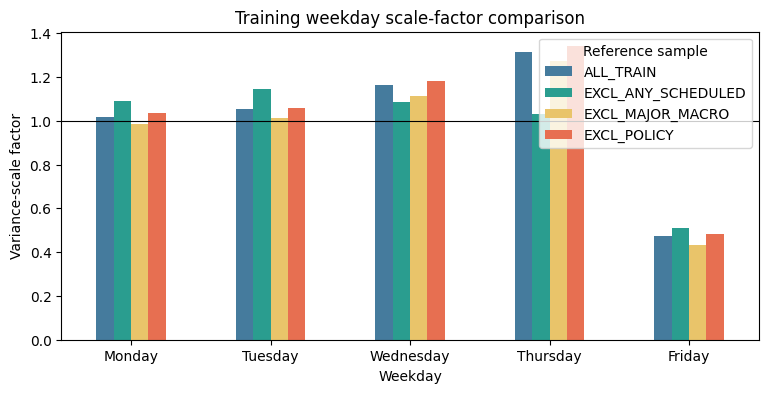

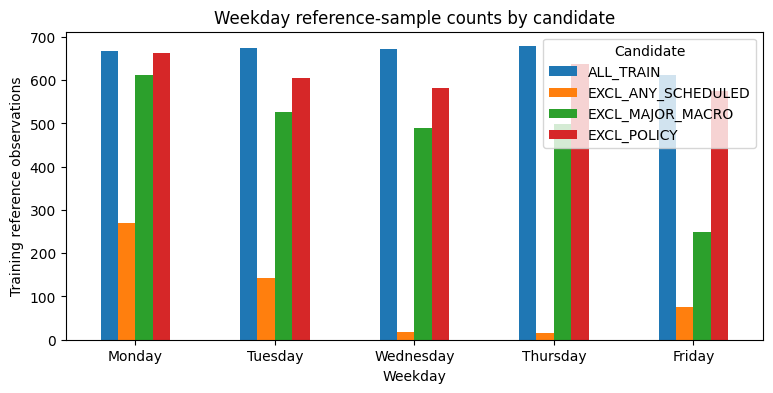

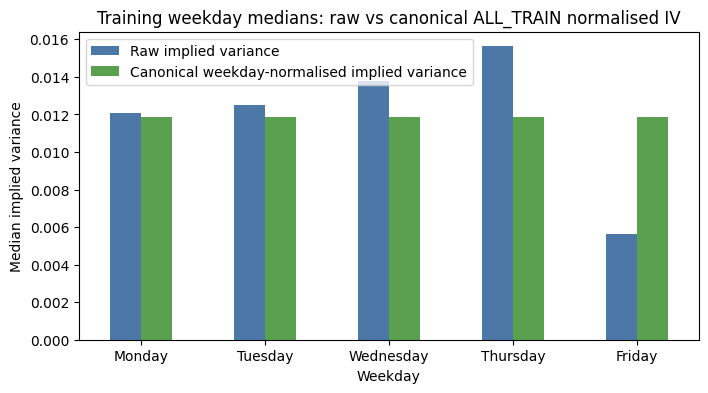

,raw_implied_variance_median,canonical_normalised_implied_variance_median
iv_weekday,,
Monday,0.012100,0.011889
Tuesday,0.012519,0.011889
Wednesday,0.013806,0.011889
Thursday,0.015625,0.011889
Friday,0.005649,0.011889


WEEKDAY NORMALISATION REFERENCE SAMPLE: FROZEN
PRIMARY REFERENCE SAMPLE: ALL_TRAIN
ROBUSTNESS REFERENCE SAMPLE: EXCL_POLICY
Training boundary: 2003-05-06 to 2017-03-27
Friday remains the dominant weekday distortion: True
EXCL_ANY_SCHEDULED rejected as primary because it is underpowered: True
Rationale: ALL_TRAIN has the largest, balanced weekday sample and uses robust medians; EXCL_POLICY produces similar factors. EXCL_MAJOR_MACRO remains an audit, while EXCL_ANY_SCHEDULED is rejected as primary because routine scheduled releases exhaust weekday support.
weekday_reference_sample_frozen                                                     True
weekday_reference_sample_primary                                               ALL_TRAIN
weekday_reference_sample_robustness                                          EXCL_POLICY
iv_raw_column                                                                 iv_ann_var
iv_canonical_model_column                                                   iv_mode

In [35]:
# Reconstruct the frozen 60/20/20 split; every candidate factor is estimated on training only.
N = len(panel)
train_end, validation_end = int(np.floor(0.60 * N)), int(np.floor(0.80 * N))
panel['weekday_factor_split'] = np.select(
    [panel.index < train_end, panel.index < validation_end],
    ['train', 'validation'], default='test',
)
if FROZEN_16_PANEL_PATH.exists():
    frozen16 = pd.read_csv(FROZEN_16_PANEL_PATH, parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True)
    assert frozen16['model_day'].equals(panel['model_day'])
    assert frozen16['sample_split'].astype(str).equals(panel['weekday_factor_split'].astype(str))
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
panel['iv_weekday'] = pd.Categorical(panel['model_day'].dt.day_name(), categories=weekday_order, ordered=True)
valid_iv = panel['iv_ann_var'].notna()
raw_iv_before_normalisation = panel['iv_ann_var'].copy()
train_iv = panel['weekday_factor_split'].eq('train') & valid_iv
assert panel.loc[train_iv, 'model_day'].max() < panel.loc[panel['weekday_factor_split'].eq('validation'), 'model_day'].min()
assert panel.loc[panel['weekday_factor_split'].eq('validation'), 'model_day'].max() < panel.loc[panel['weekday_factor_split'].eq('test'), 'model_day'].min()
assert set(panel.loc[valid_iv, 'iv_weekday'].astype(str)) == set(weekday_order)

# Exact audited labels used in the transparent policy/major-macro definitions.
POLICY_EVENT_LABELS = ['FOMC Rate Decision (Upper Bound)', 'BOJ Target Rate']
MAJOR_MACRO_EVENT_LABELS = [
    'FOMC Rate Decision (Upper Bound)', 'BOJ Target Rate',
    'Change in Nonfarm Payrolls',
    'CPI MoM', 'CPI YoY', 'Natl CPI YoY', 'Tokyo CPI Ex-Fresh Food YoY',
    'GDP Annualized QoQ', 'GDP Annualized SA QoQ', 'GDP SA QoQ', 'GDP Deflator YoY',
    'Retail Sales Advance MoM',
]
mapped_training_events = (
    events_mapped.loc[events_mapped['event_in_rv_session'], ['rv_model_day', 'ccy', 'event']]
    .merge(panel[['model_day', 'weekday_factor_split', 'iv_ann_var']], left_on='rv_model_day', right_on='model_day', how='inner')
    .loc[lambda x: x['weekday_factor_split'].eq('train') & x['iv_ann_var'].notna()]
    .copy()
)
event_calendar_training_audit = (
    mapped_training_events.groupby(['ccy', 'event'], as_index=False)
    .agg(event_rows=('event', 'size'), unique_model_days=('model_day', 'nunique'))
    .sort_values(['event_rows', 'unique_model_days'], ascending=False)
    .head(20)
)
training_calendar_coverage = pd.DataFrame([{
    'training_iv_model_days': int(train_iv.sum()),
    'any_scheduled_event_days': int((train_iv & panel['any_scheduled_event_current_session']).sum()),
    'any_scheduled_event_fraction': float(panel.loc[train_iv, 'any_scheduled_event_current_session'].mean()),
    'no_scheduled_event_days': int((train_iv & ~panel['any_scheduled_event_current_session']).sum()),
    'no_scheduled_event_fraction': float((~panel.loc[train_iv, 'any_scheduled_event_current_session']).mean()),
}])
policy_event_days = set(mapped_training_events.loc[mapped_training_events['event'].isin(POLICY_EVENT_LABELS), 'model_day'])
major_macro_event_days = set(mapped_training_events.loc[mapped_training_events['event'].isin(MAJOR_MACRO_EVENT_LABELS), 'model_day'])
event_matching_audit = pd.DataFrame([
    {'requested_category': 'US FOMC policy decision', 'exact_labels_matched': 'FOMC Rate Decision (Upper Bound)', 'event_rows': int((mapped_training_events['event'] == 'FOMC Rate Decision (Upper Bound)').sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'] == 'FOMC Rate Decision (Upper Bound)', 'model_day'].nunique())},
    {'requested_category': 'Japan BoJ policy decision', 'exact_labels_matched': 'BOJ Target Rate', 'event_rows': int((mapped_training_events['event'] == 'BOJ Target Rate').sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'] == 'BOJ Target Rate', 'model_day'].nunique())},
    {'requested_category': 'US payrolls', 'exact_labels_matched': 'Change in Nonfarm Payrolls', 'event_rows': int((mapped_training_events['event'] == 'Change in Nonfarm Payrolls').sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'] == 'Change in Nonfarm Payrolls', 'model_day'].nunique())},
    {'requested_category': 'US CPI', 'exact_labels_matched': 'CPI MoM; CPI YoY', 'event_rows': int(mapped_training_events['event'].isin(['CPI MoM', 'CPI YoY']).sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'].isin(['CPI MoM', 'CPI YoY']), 'model_day'].nunique())},
    {'requested_category': 'US GDP', 'exact_labels_matched': 'GDP Annualized QoQ', 'event_rows': int((mapped_training_events['event'] == 'GDP Annualized QoQ').sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'] == 'GDP Annualized QoQ', 'model_day'].nunique())},
    {'requested_category': 'US retail sales', 'exact_labels_matched': 'Retail Sales Advance MoM', 'event_rows': int((mapped_training_events['event'] == 'Retail Sales Advance MoM').sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'] == 'Retail Sales Advance MoM', 'model_day'].nunique())},
    {'requested_category': 'Japan CPI', 'exact_labels_matched': 'Natl CPI YoY; Tokyo CPI Ex-Fresh Food YoY', 'event_rows': int(mapped_training_events['event'].isin(['Natl CPI YoY', 'Tokyo CPI Ex-Fresh Food YoY']).sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'].isin(['Natl CPI YoY', 'Tokyo CPI Ex-Fresh Food YoY']), 'model_day'].nunique())},
    {'requested_category': 'Japan GDP', 'exact_labels_matched': 'GDP Annualized SA QoQ; GDP SA QoQ; GDP Deflator YoY', 'event_rows': int(mapped_training_events['event'].isin(['GDP Annualized SA QoQ', 'GDP SA QoQ', 'GDP Deflator YoY']).sum()), 'unique_model_days_excluded': int(mapped_training_events.loc[mapped_training_events['event'].isin(['GDP Annualized SA QoQ', 'GDP SA QoQ', 'GDP Deflator YoY']), 'model_day'].nunique())},
])
display(training_calendar_coverage)
display(event_calendar_training_audit)
display(event_matching_audit)

panel['policy_event_current_session'] = panel['model_day'].isin(policy_event_days)
panel['major_macro_event_current_session'] = panel['model_day'].isin(major_macro_event_days)
candidate_masks = {
    'ALL_TRAIN': train_iv,
    'EXCL_POLICY': train_iv & ~panel['policy_event_current_session'],
    'EXCL_MAJOR_MACRO': train_iv & ~panel['major_macro_event_current_session'],
    'EXCL_ANY_SCHEDULED': train_iv & ~panel['any_scheduled_event_current_session'],
}

def candidate_factor_table(candidate, mask):
    reference = panel.loc[mask, ['model_day', 'iv_weekday', 'iv_ann_var']].copy()
    assert reference['weekday_factor_split'].empty if 'weekday_factor_split' in reference else True
    pooled = reference['iv_ann_var'].median()
    out = reference.groupby('iv_weekday', observed=False).agg(
        n=('iv_ann_var', 'size'),
        weekday_raw_median=('iv_ann_var', 'median'),
    ).reset_index()
    out['candidate'] = candidate
    out['pooled_raw_median'] = pooled
    out['scale_factor'] = out['weekday_raw_median'] / pooled
    out['inverse_scale_factor'] = 1.0 / out['scale_factor']
    assert len(out) == 5 and out['n'].gt(0).all() and np.isfinite(out['scale_factor']).all() and out['scale_factor'].gt(0).all()
    return reference, out

candidate_references, factor_frames = {}, []
for candidate, mask in candidate_masks.items():
    reference, factor = candidate_factor_table(candidate, mask)
    candidate_references[candidate] = reference
    factor_frames.append(factor)
weekday_factor_comparison = pd.concat(factor_frames, ignore_index=True)
candidate_reference_sample_counts = (
    weekday_factor_comparison.pivot(index='candidate', columns='iv_weekday', values='n')
    .reindex(columns=weekday_order)
    .rename(columns={day: f'{day}_n' for day in weekday_order})
    .reset_index()
)
candidate_reference_sample_counts['total_n'] = candidate_reference_sample_counts[[f'{day}_n' for day in weekday_order]].sum(axis=1)
candidate_reference_sample_counts['LOW_SAMPLE_WARNING'] = candidate_reference_sample_counts[[f'{day}_n' for day in weekday_order]].min(axis=1).lt(30)
candidate_reference_sample_counts = candidate_reference_sample_counts[['candidate', 'total_n'] + [f'{day}_n' for day in weekday_order] + ['LOW_SAMPLE_WARNING']]
display(candidate_reference_sample_counts)
display(weekday_factor_comparison)

factor_pivot = weekday_factor_comparison.pivot(index='iv_weekday', columns='candidate', values='scale_factor').reindex(weekday_order)
ac = factor_pivot[['ALL_TRAIN', 'EXCL_POLICY', 'EXCL_MAJOR_MACRO']]
factor_stability = pd.DataFrame({
    'weekday': ac.index,
    'max_factor_A_to_C': ac.max(axis=1).to_numpy(),
    'min_factor_A_to_C': ac.min(axis=1).to_numpy(),
    'range_A_to_C': (ac.max(axis=1) - ac.min(axis=1)).to_numpy(),
    'percent_range_relative_to_AC_mean': ((ac.max(axis=1) - ac.min(axis=1)) / ac.mean(axis=1)).to_numpy(),
    'abs_diff_ALL_vs_EXCL_POLICY': (ac['ALL_TRAIN'] - ac['EXCL_POLICY']).abs().to_numpy(),
    'abs_diff_ALL_vs_EXCL_MAJOR_MACRO': (ac['ALL_TRAIN'] - ac['EXCL_MAJOR_MACRO']).abs().to_numpy(),
})
display(factor_pivot)
display(factor_stability)

# Stratified weekday bootstrap preserves reference-weekday support while resampling only candidate training observations.
rng = np.random.default_rng(16017)
B = 1000
bootstrap_rows = []
for candidate in ['ALL_TRAIN', 'EXCL_POLICY', 'EXCL_MAJOR_MACRO']:
    ref = candidate_references[candidate]
    values_by_day = {day: ref.loc[ref['iv_weekday'].eq(day), 'iv_ann_var'].to_numpy(float) for day in weekday_order}
    draws = np.empty((B, len(weekday_order)))
    for b in range(B):
        samples = {day: rng.choice(values_by_day[day], size=len(values_by_day[day]), replace=True) for day in weekday_order}
        pooled = np.median(np.concatenate(list(samples.values())))
        draws[b] = [np.median(samples[day]) / pooled for day in weekday_order]
    point = factor_pivot.loc[weekday_order, candidate].to_numpy(float)
    for j, day in enumerate(weekday_order):
        bootstrap_rows.append({
            'candidate': candidate, 'weekday': day, 'point_estimate': point[j],
            'bootstrap_ci_2_5': np.quantile(draws[:, j], .025),
            'bootstrap_ci_97_5': np.quantile(draws[:, j], .975),
            'bootstrap_standard_error': np.std(draws[:, j], ddof=1),
            'bootstrap_resamples': B, 'bootstrap_design': 'weekday-stratified iid resampling within candidate training reference sample',
        })
weekday_factor_bootstrap = pd.DataFrame(bootstrap_rows)
display(weekday_factor_bootstrap)

# Construct all candidate transformations for audit; exclusions affect estimation only, never panel retention.
for candidate, col in [
    ('ALL_TRAIN', 'iv_weekday_norm_all_train'),
    ('EXCL_POLICY', 'iv_weekday_norm_excl_policy'),
    ('EXCL_MAJOR_MACRO', 'iv_weekday_norm_excl_major_macro'),
    ('EXCL_ANY_SCHEDULED', 'iv_weekday_norm_excl_any_scheduled'),
]:
    lookup = factor_pivot[candidate]
    panel[col] = panel['iv_ann_var'] / panel['iv_weekday'].map(lookup).astype(float)
    assert panel[col].notna().eq(panel['iv_ann_var'].notna()).all()

# FINAL FROZEN DECISION: ALL_TRAIN is canonical; EXCL_POLICY is the primary robustness alternative.
PRIMARY_REFERENCE_SAMPLE = 'ALL_TRAIN'
ROBUSTNESS_REFERENCE_SAMPLE = 'EXCL_POLICY'
primary_factor_table = (
    weekday_factor_comparison.loc[weekday_factor_comparison['candidate'].eq(PRIMARY_REFERENCE_SAMPLE)]
    .copy()
    .sort_values('iv_weekday')
)
primary_factor_table['iv_weekday'] = pd.Categorical(primary_factor_table['iv_weekday'], categories=weekday_order, ordered=True)
primary_factor_table = primary_factor_table.sort_values('iv_weekday').reset_index(drop=True)
primary_factor_lookup = primary_factor_table.set_index('iv_weekday')['scale_factor'].reindex(weekday_order)
assert len(primary_factor_table) == 5
assert primary_factor_table['n'].gt(0).all()
assert np.isfinite(primary_factor_lookup.to_numpy(float)).all() and primary_factor_lookup.gt(0).all()
assert candidate_masks[PRIMARY_REFERENCE_SAMPLE].eq(train_iv).all()
assert candidate_references[PRIMARY_REFERENCE_SAMPLE]['model_day'].isin(panel.loc[train_iv, 'model_day']).all()
assert not candidate_references[PRIMARY_REFERENCE_SAMPLE]['model_day'].isin(panel.loc[~panel['weekday_factor_split'].eq('train'), 'model_day']).any()

# Every IV observation receives its frozen ALL_TRAIN weekday factor. Raw IV is preserved.
panel['iv_weekday_scale'] = panel['iv_weekday'].map(primary_factor_lookup).astype(float)
panel['iv_weekday_norm_var'] = panel['iv_ann_var'] / panel['iv_weekday_scale']
panel['iv_model_var'] = panel['iv_weekday_norm_var']
assert np.allclose(panel.loc[valid_iv, 'iv_ann_var'], raw_iv_before_normalisation.loc[valid_iv])
assert panel.loc[valid_iv, 'iv_weekday_scale'].notna().all()
assert np.allclose(panel.loc[valid_iv, 'iv_weekday_norm_var'], panel.loc[valid_iv, 'iv_ann_var'] / panel.loc[valid_iv, 'iv_weekday_scale'])
assert np.allclose(panel.loc[valid_iv, 'iv_model_var'], panel.loc[valid_iv, 'iv_weekday_norm_var'])
assert np.allclose(panel.loc[valid_iv, 'iv_weekday_norm_var'], panel.loc[valid_iv, 'iv_weekday_norm_all_train'])
assert panel['iv_weekday_norm_var'].notna().eq(panel['iv_ann_var'].notna()).all()
for day in weekday_order:
    values = panel.loc[panel['iv_weekday'].eq(day) & valid_iv, 'iv_weekday_scale']
    assert values.nunique(dropna=True) == 1 and np.isclose(values.iloc[0], primary_factor_lookup.loc[day])

# The audit must leave the realised side, model-day chronology, and same-date event mapping unchanged.
if previous_panel is not None:
    previous = previous_panel.set_index('model_day')
    current = panel.set_index('model_day')
    assert current.index.equals(previous.index)
    preserved_realised_columns = [
        'expected_hourly_return_count', 'observed_hourly_count', 'valid_hourly_return_count',
        'within_session_log_return_raw', 'within_session_log_return', 'total_cut_to_cut_log_return',
        'rv_within_raw', 'rv_within', 'rv_with_closure_gap_raw', 'rv_with_closure_gap',
        'rv_eligible', 'rv_full_session_stale', 'closure_gap_log_return', 'closure_gap_type',
    ]
    for column in preserved_realised_columns + ['iv_ann_var', 'any_scheduled_event_current_session', 'scheduled_event_count_current_session']:
        assert column in previous.columns
        if pd.api.types.is_numeric_dtype(current[column]) or pd.api.types.is_bool_dtype(current[column]):
            assert np.allclose(current[column].to_numpy(float), previous[column].to_numpy(float), equal_nan=True)
        else:
            assert current[column].astype(str).equals(previous[column].astype(str))
assert panel['model_day'].is_monotonic_increasing and panel['model_day'].is_unique
assert panel.loc[panel['model_day'].isin(pd.to_datetime(['2013-01-01', '2014-01-01'])), 'rv_full_session_stale'].all()
assert (~panel.loc[panel['model_day'].isin(pd.to_datetime(['2013-01-01', '2014-01-01'])), 'rv_eligible']).all()

primary_factor_export = primary_factor_table.rename(columns={
    'iv_weekday': 'weekday', 'weekday_raw_median': 'raw_weekday_median',
})[['candidate', 'weekday', 'n', 'raw_weekday_median', 'pooled_raw_median', 'scale_factor', 'inverse_scale_factor']].copy()
primary_factor_export = primary_factor_export.drop(columns='candidate')
primary_factor_export.insert(0, 'reference_sample', PRIMARY_REFERENCE_SAMPLE)
primary_factor_export['primary_flag'] = True

policy_factor_comparison = pd.DataFrame({
    'weekday': weekday_order,
    'ALL_TRAIN_factor': factor_pivot.loc[weekday_order, 'ALL_TRAIN'].to_numpy(float),
    'EXCL_POLICY_factor': factor_pivot.loc[weekday_order, 'EXCL_POLICY'].to_numpy(float),
})
policy_factor_comparison['absolute_difference'] = (policy_factor_comparison['ALL_TRAIN_factor'] - policy_factor_comparison['EXCL_POLICY_factor']).abs()
policy_factor_comparison['percentage_difference_vs_ALL_TRAIN'] = (
    policy_factor_comparison['absolute_difference'] / policy_factor_comparison['ALL_TRAIN_factor'] * 100
)
display(primary_factor_export)
display(policy_factor_comparison)

candidate_audit_rows = []
for candidate in ['ALL_TRAIN', 'EXCL_POLICY', 'EXCL_MAJOR_MACRO']:
    col = {
        'ALL_TRAIN': 'iv_weekday_norm_all_train',
        'EXCL_POLICY': 'iv_weekday_norm_excl_policy',
        'EXCL_MAJOR_MACRO': 'iv_weekday_norm_excl_major_macro',
    }[candidate]
    for scope, frame in [('candidate_training_reference', candidate_references[candidate]), ('all_training_iv', panel.loc[train_iv])]:
        work = frame[['model_day', 'iv_weekday', 'iv_ann_var']].merge(panel[['model_day', col]], on='model_day', how='left', validate='one_to_one')
        summary = work.groupby('iv_weekday', observed=False).agg(
            n=('iv_ann_var', 'size'), median_raw_implied_variance=('iv_ann_var', 'median'),
            median_normalised_implied_variance=(col, 'median'),
        ).reset_index()
        raw_pool, norm_pool = work['iv_ann_var'].median(), work[col].median()
        summary['candidate'] = candidate
        summary['scope'] = scope
        summary['raw_median_relative_to_pooled'] = summary['median_raw_implied_variance'] / raw_pool
        summary['normalised_median_relative_to_pooled'] = summary['median_normalised_implied_variance'] / norm_pool
        candidate_audit_rows.append(summary)
        if scope == 'candidate_training_reference':
            assert np.allclose(summary['median_normalised_implied_variance'], raw_pool, rtol=1e-10, atol=1e-14)
iv_weekday_normalisation_candidate_audit = pd.concat(candidate_audit_rows, ignore_index=True)
display(iv_weekday_normalisation_candidate_audit)

fig, ax = plt.subplots(figsize=(9, 4))
factor_pivot.plot(kind='bar', ax=ax, color=['#457b9d', '#2a9d8f', '#e9c46a', '#e76f51'])
ax.axhline(1, color='black', linewidth=.8)
ax.set_ylabel('Variance-scale factor'); ax.set_xlabel('Weekday')
ax.set_title('Training weekday scale-factor comparison')
ax.legend(title='Reference sample')
plt.xticks(rotation=0); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
count_plot = candidate_reference_sample_counts.set_index('candidate')[[f'{day}_n' for day in weekday_order]]
count_plot.columns = weekday_order
count_plot.T.plot(kind='bar', ax=ax)
ax.set_ylabel('Training reference observations'); ax.set_xlabel('Weekday')
ax.set_title('Weekday reference-sample counts by candidate')
ax.legend(title='Candidate')
plt.xticks(rotation=0); plt.show()

# Final primary diagnostic: equality after normalisation is constructed seasonal adjustment, not evidence of equal economic volatility.
final_primary_weekday_medians = (
    panel.loc[train_iv].groupby('iv_weekday', observed=False)
    .agg(raw_implied_variance_median=('iv_ann_var', 'median'),
         canonical_normalised_implied_variance_median=('iv_weekday_norm_var', 'median'))
    .reindex(weekday_order)
)
fig, ax = plt.subplots(figsize=(8, 4))
final_primary_weekday_medians.plot(kind='bar', ax=ax, color=['#4c78a8', '#59a14f'])
ax.set_ylabel('Median implied variance')
ax.set_xlabel('Weekday')
ax.set_title('Training weekday medians: raw vs canonical ALL_TRAIN normalised IV')
ax.legend(['Raw implied variance', 'Canonical weekday-normalised implied variance'])
plt.xticks(rotation=0); plt.show()
display(final_primary_weekday_medians)

broad_underpowered = bool(candidate_reference_sample_counts.loc[
    candidate_reference_sample_counts['candidate'].eq('EXCL_ANY_SCHEDULED'), 'LOW_SAMPLE_WARNING'
].iloc[0])
friday_dominant = bool(primary_factor_lookup.loc['Friday'] == primary_factor_lookup.min())
weekday_reference_recommendation = PRIMARY_REFERENCE_SAMPLE
weekday_reference_status = 'WEEKDAY NORMALISATION REFERENCE SAMPLE: FROZEN'
recommendation_reason = (
    'ALL_TRAIN has the largest, balanced weekday sample and uses robust medians; EXCL_POLICY produces similar factors. '
    'EXCL_MAJOR_MACRO remains an audit, while EXCL_ANY_SCHEDULED is rejected as primary because routine scheduled releases exhaust weekday support.'
)
weekday_finalisation_status = pd.Series({
    'weekday_reference_sample_frozen': True,
    'weekday_reference_sample_primary': PRIMARY_REFERENCE_SAMPLE,
    'weekday_reference_sample_robustness': ROBUSTNESS_REFERENCE_SAMPLE,
    'iv_raw_column': 'iv_ann_var',
    'iv_canonical_model_column': 'iv_model_var',
    'iv_canonical_model_definition': 'weekday-normalised raw implied variance using ALL_TRAIN training-period median weekday factors',
    'units_changed': False,
    'event_dates_removed': False,
    'event_alignment_changed': False,
    'realised_variance_changed': False,
    'notebook_15_ready_to_freeze': True,
    'notebook_16_requires_rerun': True,
})
print(weekday_reference_status)
print('PRIMARY REFERENCE SAMPLE:', PRIMARY_REFERENCE_SAMPLE)
print('ROBUSTNESS REFERENCE SAMPLE:', ROBUSTNESS_REFERENCE_SAMPLE)
print('Training boundary:', panel.loc[train_iv, 'model_day'].min().date(), 'to', panel.loc[train_iv, 'model_day'].max().date())
print('Friday remains the dominant weekday distortion:', friday_dominant)
print('EXCL_ANY_SCHEDULED rejected as primary because it is underpowered:', broad_underpowered)
print('Rationale:', recommendation_reason)
print(weekday_finalisation_status.to_string())


## Frozen canonical implied-variance state and handoff

The raw state is retained as I_t^{raw}=(q_t/100)^2 in iv_ann_var. Four reference samples were audited; excluding every scheduled event is not used as the primary estimator because it produces highly uneven reference support. The canonical state is iv_model_var = iv_weekday_norm_var = I_t^{raw}/s_{weekday(t)}^{ALL_TRAIN}; EXCL_POLICY remains the primary robustness alternative.

The final training-sample median figure shows the raw weekday pattern beside the canonical normalised medians. Equal post-normalisation medians are a constructed consequence of this seasonal adjustment; they do not prove that underlying economic volatility is identical across weekdays.

The transformation is a dimensionless multiplicative weekday seasonal adjustment. It does not establish why Fridays are depressed, does not make a claim about a Bloomberg weekend or day-count convention, and does not change physical units. It deliberately retains all valid event and non-event dates, leaves same-date IV/event alignment unchanged, and does not infer the unresolved Bloomberg intraday quote time.

Because the canonical implied-variance state has changed, Notebook 16 must rerun its lag-order selection, GC, and TDMI analysis using iv_model_var. Notebook 16 and Notebook 17 are not modified here.


In [36]:
hourly_export = hourly.drop(columns=['timestamp_ny'], errors='ignore')
hourly_path = PROCESSED / 'usdjpy_hourly_modelday_returns.csv'
daily_path = PROCESSED / 'usdjpy_daily_model_panel.csv'
events_path = PROCESSED / 'g10_usd_jpy_events_modelday_mapped.csv'
reference_counts_path = PROCESSED / '15_iv_weekday_reference_sample_counts.csv'
factor_comparison_path = PROCESSED / '15_iv_weekday_factor_comparison.csv'
bootstrap_path = PROCESSED / '15_iv_weekday_factor_bootstrap.csv'
candidate_audit_path = PROCESSED / '15_iv_weekday_normalisation_candidate_audit.csv'
primary_factors_path = PROCESSED / '15_iv_weekday_scale_factors.csv'
finalisation_path = PROCESSED / '15_iv_weekday_normalisation_final.csv'

def write_csv_with_retry(frame, path, attempts=3):
    import time
    for attempt in range(attempts):
        try:
            frame.to_csv(path, index=False)
            return
        except OSError:
            if attempt + 1 == attempts:
                raise
            time.sleep(1)

write_csv_with_retry(hourly_export, hourly_path)
write_csv_with_retry(panel, daily_path)
write_csv_with_retry(events_mapped, events_path)
for frame, path in [(candidate_reference_sample_counts, reference_counts_path), (weekday_factor_comparison, factor_comparison_path), (weekday_factor_bootstrap, bootstrap_path), (iv_weekday_normalisation_candidate_audit, candidate_audit_path), (primary_factor_export, primary_factors_path), (weekday_finalisation_status.rename_axis('field').reset_index(name='value'), finalisation_path)]:
    export_frame = frame.copy()
    export_frame.insert(0, 'RUN_ID', RUN_ID)
    write_csv_with_retry(export_frame, path)
final_summary = pd.Series({
    'model_sessions': len(panel),
    'rv_eligible_days': int(panel.rv_eligible.sum()),
    'rv_eligible_pct': float(panel.rv_eligible.mean()),
    'iv_available_days': int(panel.iv_available.sum()),
    'weekday_factor_reference_recommendation': weekday_reference_recommendation,
    'weekday_factor_reference_status': weekday_reference_status,
    'weekday_factor_primary_reference': PRIMARY_REFERENCE_SAMPLE,
    'weekday_factor_robustness_reference': ROBUSTNESS_REFERENCE_SAMPLE,
    'notebook_16_requires_rerun': True,
    'weekday_normalised_iv_available_days': int(panel.iv_weekday_norm_var.notna().sum()),
    'current_joint_panel_eligible_days': int(panel.joint_panel_eligible.sum()),
    'forecast_pair_eligible_days': int(panel.forecast_pair_eligible.sum()),
    'current_joint_lost_only_next_rv_unavailable': int((panel.joint_panel_eligible & ~panel.forecast_pair_eligible).sum()),
    'rv_ineligible_days_with_raw_rv': int((~panel.rv_eligible & panel.rv_within_raw.notna()).sum()),
    'eligible_monday_sessions': int(panel.eligible_monday_session.sum()),
    'weekend_reopening_gaps_constructed': int((panel.closure_gap_type == 'weekend').sum()),
    'weekend_reopening_gaps_missing': int((panel.eligible_monday_session & panel.closure_gap_type.ne('weekend')).sum()),
    'rv_only_days': int((panel.rv_eligible & ~panel.iv_available).sum()),
    'iv_only_days': int((~panel.rv_eligible & panel.iv_available).sum()),
    'rv_iv_both_days': int((panel.rv_eligible & panel.iv_available).sum()),
    'rv_iv_neither_days': int((~panel.rv_eligible & ~panel.iv_available).sum()),
    'events_in_rv_session': int(events_mapped.event_in_rv_session.sum()),
    'events_market_closure_within_sample': int(events_mapped.event_in_market_closure.sum()),
    'events_outside_model_sample': int(events_mapped.event_outside_model_sample.sum()),
    'events_other_unresolved': int((events_mapped.event_status == 'other/unresolved').sum()),
    'cut_to_cut_max_abs_difference': float(cut_stats['max_abs_difference']),
    'cut_to_cut_p99_abs_difference': float(cut_stats['p99_abs_difference']),
})
print(final_summary.to_string())
print('Regenerated:', hourly_path.name, daily_path.name, events_path.name, reference_counts_path.name, factor_comparison_path.name, bootstrap_path.name, candidate_audit_path.name, primary_factors_path.name, finalisation_path.name)

model_sessions                                                                           6044
rv_eligible_days                                                                         5762
rv_eligible_pct                                                                      0.953342
iv_available_days                                                                        5719
weekday_factor_reference_recommendation                                             ALL_TRAIN
weekday_factor_reference_status                WEEKDAY NORMALISATION REFERENCE SAMPLE: FROZEN
weekday_factor_primary_reference                                                    ALL_TRAIN
weekday_factor_robustness_reference                                               EXCL_POLICY
notebook_16_requires_rerun                                                               True
weekday_normalised_iv_available_days                                                     5719
current_joint_panel_eligible_days                           